In [4]:
import pandas as pd
df = pd.read_csv("Motown_Era.csv")

In [5]:
df.head()

,Track URI,Track Name,Album Name,Artist Name(s),Release Date,Duration (ms),Popularity,Explicit,Added By,Added At,...,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,spotify:track:5ou2nZT8UQJn1nuiUxAyjs,Ain't No Sunshine,Got To Be There,Michael Jackson,1972-01-24,253466,53,False,jn3vg545bmz7gns7tlnk04mcm,2026-05-14T18:04:19Z,...,5,-9.903,0,0.0511,0.0281,0.000022,0.0796,0.736,151.991,4
1,spotify:track:3mnVgyzn5HC7Sqkn3B5zHs,I Wanna Be Where You Are,Got To Be There,Michael Jackson,1972-01-24,182786,55,False,jn3vg545bmz7gns7tlnk04mcm,2026-05-14T18:04:19Z,...,4,-8.546,0,0.0604,0.4690,0.002350,0.1180,0.662,103.817,4
2,spotify:track:2laojQD1QCqjvmMn8lFlPk,Girl Don't Take Your Love From Me,Got To Be There,Michael Jackson,1972-01-24,231013,47,False,jn3vg545bmz7gns7tlnk04mcm,2026-05-14T18:04:19Z,...,2,-8.564,0,0.0264,0.2120,0.000000,0.0573,0.779,176.403,4
3,spotify:track:6m6WAwH7v59fGJQz2luaXN,In Our Small Way,Got To Be There,Michael Jackson,1972-01-24,221933,44,False,jn3vg545bmz7gns7tlnk04mcm,2026-05-14T18:04:19Z,...,4,-8.571,1,0.0281,0.5080,0.000000,0.1560,0.581,180.979,4
4,spotify:track:08QvVJT8y6b0i2nH9mUeMj,Got To Be There - Single Version,Got To Be There,Michael Jackson,1972-01-24,204906,51,False,jn3vg545bmz7gns7tlnk04mcm,2026-05-14T18:04:19Z,...,1,-9.512,1,0.0434,0.1100,0.000122,0.0416,0.721,171.354,4


In [6]:
df.columns

Index(['Track URI', 'Track Name', 'Album Name', 'Artist Name(s)',
       'Release Date', 'Duration (ms)', 'Popularity', 'Explicit', 'Added By',
       'Added At', 'Genres', 'Record Label', 'Danceability', 'Energy', 'Key',
       'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Liveness', 'Valence', 'Tempo', 'Time Signature'],
      dtype='object')

In [7]:
songs = df[["Track Name", "Artist Name(s)"]].copy()

In [8]:
songs

,Track Name,Artist Name(s)
0,Ain't No Sunshine,Michael Jackson
1,I Wanna Be Where You Are,Michael Jackson
2,Girl Don't Take Your Love From Me,Michael Jackson
3,In Our Small Way,Michael Jackson
4,Got To Be There - Single Version,Michael Jackson
5,Rockin' Robin,Michael Jackson
6,Wings Of My Love,Michael Jackson
7,Maria (You Were The Only One) - Single Version,Michael Jackson
8,Love Is Here And Now You're Gone,Michael Jackson
9,You've Got A Friend,Michael Jackson


In [9]:
import lyricsgenius

In [10]:
import os
from dotenv import load_dotenv
from pathlib import Path

load_dotenv(Path("untitled.txt"))
genius = lyricsgenius.Genius(os.environ.get("GENIUS_ACCESS_TOKEN"))

In [11]:
###Great question! Breaking it down: genius — our Genius connection we just created, .skip_non_songs — this is a setting on the genius object, = True — we're turning this setting on
# What it does in plain English: When we search for a song on Genius, sometimes it returns things that aren't actually songs — like album descriptions, artist bios, interviews, or annotation pages. Setting this to True tells lyricsgenius "ignore anything that isn't an actual song, only give me real song lyrics."
genius.skip_non_songs = True

In [12]:
genius.excluded_terms = ["(Remix)", "(Live)", "Book", "Chapter"]

In [13]:
lyrics_list = []

In [14]:
for i, row in songs.iterrows():
    print(row["Track Name"])

Ain't No Sunshine
I Wanna Be Where You Are
Girl Don't Take Your Love From Me
In Our Small Way
Got To Be There - Single Version
Rockin' Robin
Wings Of My Love
Maria (You Were The Only One) - Single Version
Love Is Here And Now You're Gone
You've Got A Friend
Ben - Single Version
Greatest Show On Earth
People Make The World Go 'Round
We've Got A Good Thing Going
Everybody's Somebody's Fool
My Girl
What Goes Around Comes Around
In Our Small Way
Shoo-Be-Doo-Be-Doo-Da-Day
You Can Cry On My Shoulder
With A Child's Heart
Up Again
All The Things You Are
Happy (Love Theme From "Lady Sings The Blues")
Too Young
Doggin' Around
Johnny Raven
Euphoria
Morning Glow
Music And Me
We're Almost There
Take Me Back
One Day In Your Life
Cinderella Stay Awhile
We've Got Forever
Just A Little Bit Of You
You Are There
Dapper Dan
Dear Michael
I'll Come Home To You


In [ ]:
for i, row in songs.iterrows():
    song = genius.search_song(
        title=row["Track Name"],
        artist=row["Artist Name(s)"]
    )

    if song:
        lyrics_list.append(song.lyrics)
    else:
        lyrics_list.append(None)

In [13]:
songs["lyrics"] = lyrics_list

In [14]:
songs.head()

,Track Name,Artist Name(s),lyrics
0,Ain't No Sunshine,Michael Jackson,[Intro]\nYou ever want something\nThat you kno...
1,I Wanna Be Where You Are,Michael Jackson,[Intro]\n(Oh!)\n\n[Verse 1]\nCan it be I staye...
2,Girl Don't Take Your Love From Me,Michael Jackson,"[Intro]\n(No, no, no)\n(No, no, no) No, no\n(N..."
3,In Our Small Way,Michael Jackson,[Intro]\nMaybe you and I can't do great things...
4,Got To Be There - Single Version,Michael Jackson,[Verse 1]\nI'm gonna make a change\nFor once i...


In [16]:
audio_df = pd.read_csv("Motown_Era.csv")
songs = audio_df.merge(songs[["Track Name", "Artist Name(s)", "lyrics"]],
                       on=["Track Name", "Artist Name(s)"],
                       how="left")

In [17]:
songs.to_csv("Motown_Era_with_lyrics.csv", index=False)

In [18]:
import os
os.getcwd()

'C:\\Users\\HP\\Motown_Era_MJ'

In [19]:
df = pd.read_csv("Motown_Era_with_lyrics.csv")


In [20]:
import re
from collections import Counter
from nltk.corpus import stopwords

In [21]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')       # useful for tokenization later
nltk.download('wordnet')  

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [23]:
lyrics = " ".join(df["lyrics"].dropna())

clean_lyrics = re.sub(r'\[.*?\]', '', lyrics)
clean_lyrics = re.sub(r'[^\w\s]', '', clean_lyrics)

stop_words = set(stopwords.words('english'))
text = clean_lyrics.lower().split()
clean_text = [word for word in text if word not in stop_words and len(word) > 2]
word_counts = Counter(clean_text)
word_counts.most_common(20)

[('love', 174),
 ('got', 142),
 ('yeah', 113),
 ('ooh', 86),
 ('know', 76),
 ('dont', 67),
 ('around', 62),
 ('baby', 62),
 ('change', 57),
 ('girl', 55),
 ('things', 55),
 ('make', 55),
 ('take', 54),
 ('world', 52),
 ('day', 51),
 ('one', 50),
 ('youre', 49),
 ('gone', 45),
 ('gonna', 45),
 ('johnny', 43)]

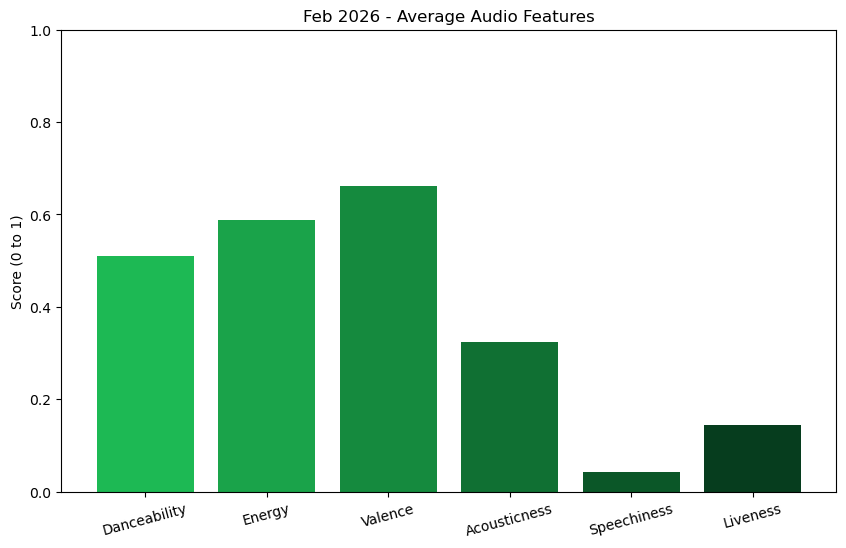

In [24]:
import matplotlib.pyplot as plt
import numpy as np

features = ['Danceability', 'Energy', 'Valence', 'Acousticness', 'Speechiness', 'Liveness']

averages = df[features].mean()

plt.figure(figsize=(10, 6))
plt.bar(features, averages, color=['#1DB954', '#1aa34a', '#158a3e', '#107033', '#0b5728', '#063d1e'])
plt.title('Feb 2026 - Average Audio Features')
plt.ylabel('Score (0 to 1)')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

In [25]:
print(df.columns)

Index(['Track URI', 'Track Name', 'Album Name', 'Artist Name(s)',
       'Release Date', 'Duration (ms)', 'Popularity', 'Explicit', 'Added By',
       'Added At', 'Genres', 'Record Label', 'Danceability', 'Energy', 'Key',
       'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Liveness', 'Valence', 'Tempo', 'Time Signature', 'lyrics'],
      dtype='object')


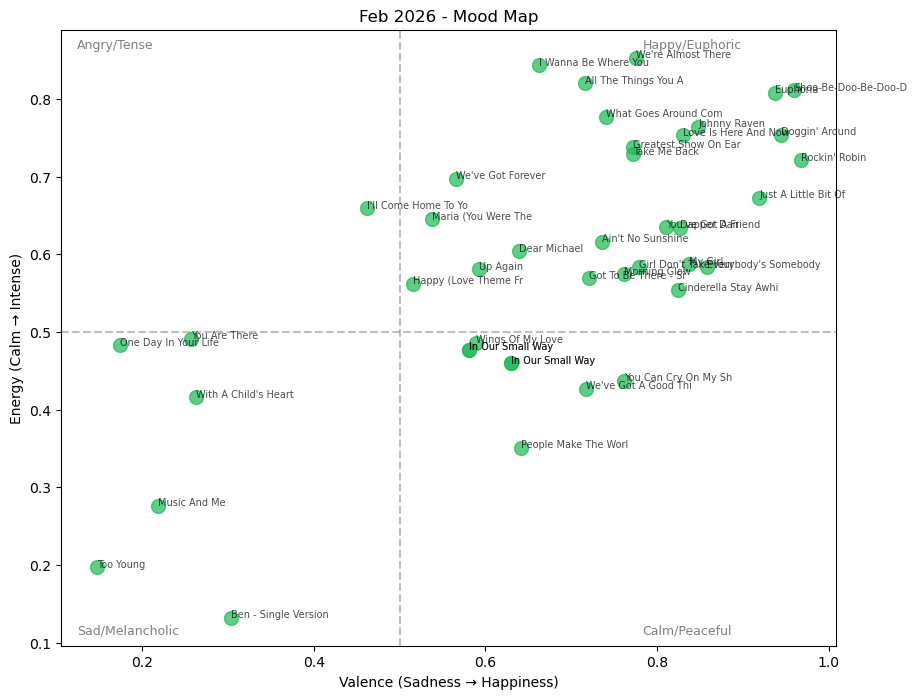

In [26]:
plt.figure(figsize=(10, 8))

plt.scatter(df['Valence'], df['Energy'], alpha=0.7, s=100, color='#1DB954')

for i, row in df.iterrows():
    plt.annotate(row['Track Name'][:20],
                (row['Valence'], row['Energy']),
                fontsize=7, alpha=0.7)

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

plt.text(0.02, 0.97, 'Angry/Tense', transform=plt.gca().transAxes, fontsize=9, color='gray')
plt.text(0.75, 0.97, 'Happy/Euphoric', transform=plt.gca().transAxes, fontsize=9, color='gray')
plt.text(0.02, 0.02, 'Sad/Melancholic', transform=plt.gca().transAxes, fontsize=9, color='gray')
plt.text(0.75, 0.02, 'Calm/Peaceful', transform=plt.gca().transAxes, fontsize=9, color='gray')

plt.xlabel('Valence (Sadness → Happiness)')
plt.ylabel('Energy (Calm → Intense)')
plt.title('Feb 2026 - Mood Map')
plt.show()

In [31]:
!pip install transformers

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
    --------------------------------------- 0.3/10.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/10.6 MB 2.5 MB/s eta 0:00:04
   -- ------------------------------------- 0.8/10.6 MB 2.5 MB/s eta 0:00:04
   ----- ---------------------------------- 1.6/10.6 MB 1.8 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/10.6 MB 1.8 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/10.6 MB 1.8 MB/s eta 0:00:05
   ------ --------------------------------- 1.8/10.6 MB 1.3 MB/s eta 0:00:07
   ------- -------------------------------- 2.1/10.6 MB 1.3 MB/s eta 0:00:07
   ------- -------------------------------- 2.1/10.6 MB 1.3 MB/s eta 0:00:07
   ------- -------------------------------- 2.1/10.6 MB 1.3 MB/s eta 0:00:07
   ---------- -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [32]:
!pip install torch

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
    --------------------------------------- 1.6/123.0 MB 5.2 MB/s eta 0:00:24
   -- ------------------------------------- 7.1/123.0 MB 13.8 MB/s eta 0:00:09
   -- ------------------------------------- 7.3/123.0 MB 9.7 MB/s eta 0:00:12
   -- ------------------------------------- 8.1/123.0 MB 8.6 MB/s eta 0:00:14
   -- ------------------------------------- 8.1/123.0 MB 8.6 MB/s eta 0:00:14
   -- ------------------------------------- 8.4/123.0 MB 6.8 MB/s eta 0:00:17
   -- ------------------------------------- 8.7/123.0 MB 6.0 MB/s eta 0:00:19
   -- ------------------------------------- 8.9/123.0 MB 5.0 MB/s eta 0:00:24
   -- ------------------------------------- 8.9/123.0 MB 5.0 MB/s eta 0:00:24
   -- 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [27]:
from transformers import pipeline

emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [28]:
def get_emotion(lyrics):
    if not isinstance(lyrics, str):
        return "unknown"
    # trim lyrics to first 500 characters as model has a limit
    trimmed = lyrics[:500]
    result = emotion_classifier(trimmed)
    return result[0][0]['label']

df['emotion'] = df['lyrics'].apply(get_emotion)
print(df[['Track Name', 'emotion']])

                                        Track Name   emotion
0                                Ain't No Sunshine   sadness
1                         I Wanna Be Where You Are  surprise
2                Girl Don't Take Your Love From Me   disgust
3                                 In Our Small Way   neutral
4                                 In Our Small Way   neutral
5                 Got To Be There - Single Version   sadness
6                                    Rockin' Robin   neutral
7                                 Wings Of My Love   sadness
8   Maria (You Were The Only One) - Single Version   neutral
9                 Love Is Here And Now You're Gone   sadness
10                             You've Got A Friend   sadness
11                            Ben - Single Version   sadness
12                          Greatest Show On Earth       joy
13                 People Make The World Go 'Round     anger
14                    We've Got A Good Thing Going       joy
15                     E

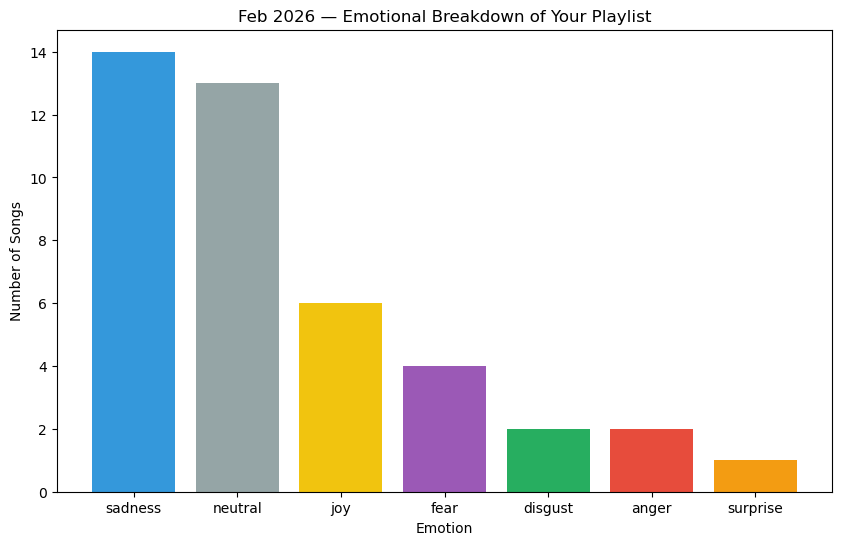

In [29]:
import matplotlib.pyplot as plt

emotion_counts = df['emotion'].value_counts()

colors = {
    'anger': '#e74c3c',
    'fear': '#9b59b6',
    'sadness': '#3498db',
    'neutral': '#95a5a6',
    'disgust': '#27ae60',
    'surprise': '#f39c12',
    'joy': '#f1c40f'
}

bar_colors = [colors.get(e, 'gray') for e in emotion_counts.index]

plt.figure(figsize=(10, 6))
plt.bar(emotion_counts.index, emotion_counts.values, color=bar_colors)
plt.title('Feb 2026 — Emotional Breakdown of Your Playlist')
plt.xlabel('Emotion')
plt.ylabel('Number of Songs')
plt.show()

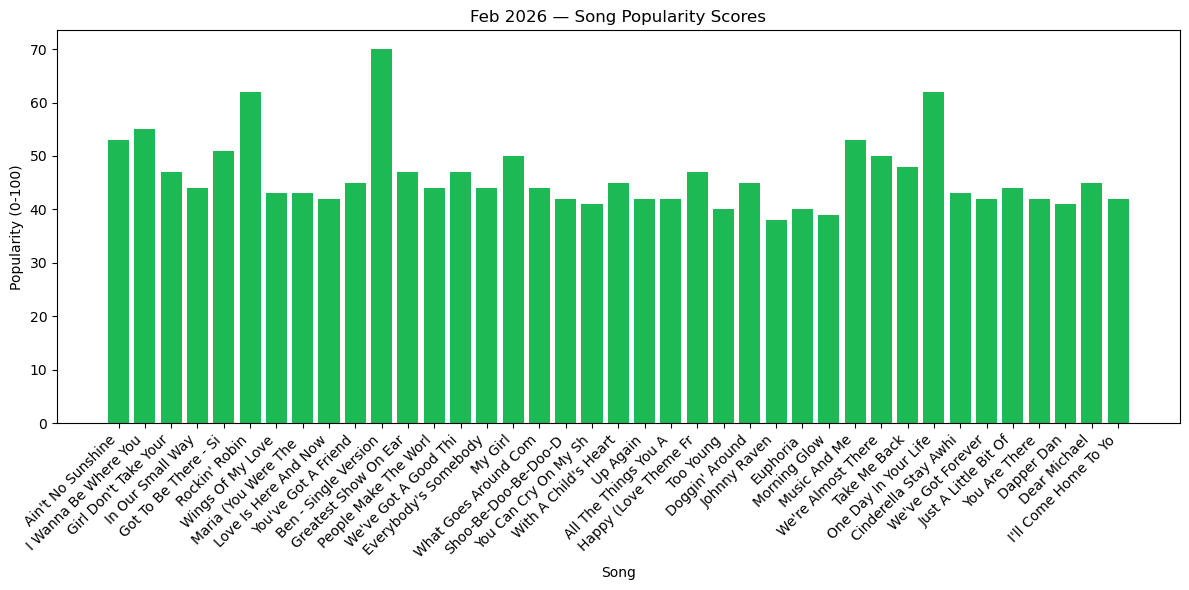

Average popularity: 46.0
Most popular song: Ben - Single Version
Least popular song: Johnny Raven


In [30]:
plt.figure(figsize=(12, 6))
plt.bar(df['Track Name'].str[:20], df['Popularity'], color='#1DB954')
plt.title('Feb 2026 — Song Popularity Scores')
plt.xlabel('Song')
plt.ylabel('Popularity (0-100)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Average popularity: {df['Popularity'].mean():.1f}")
print(f"Most popular song: {df.loc[df['Popularity'].idxmax(), 'Track Name']}")
print(f"Least popular song: {df.loc[df['Popularity'].idxmin(), 'Track Name']}")

In [31]:
import pandas as pd

df = pd.read_csv("Motown_Era.csv")
df.describe()

,Duration (ms),Popularity,Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
count,40.000000,40.000000,0.0,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,199368.700000,46.150000,NaN,0.520250,0.594000,5.675000,-9.659200,0.750000,0.043325,0.314140,0.003483,0.142973,0.664875,132.417100,3.950000
std,29792.096771,6.689257,NaN,0.132735,0.172072,3.611857,1.731854,0.438529,0.018452,0.206244,0.010546,0.086009,0.224137,34.762357,0.220721
min,154840.000000,38.000000,NaN,0.274000,0.132000,0.000000,-13.084000,0.000000,0.024100,0.014200,0.000000,0.041600,0.147000,68.152000,3.000000
25%,177770.000000,42.000000,NaN,0.442000,0.485250,3.750000,-10.968250,0.750000,0.030350,0.153500,0.000006,0.082150,0.577250,101.477500,4.000000
50%,194806.500000,44.000000,NaN,0.539000,0.595500,5.000000,-9.607500,1.000000,0.035900,0.274000,0.000081,0.116500,0.728500,134.264000,4.000000
75%,217109.750000,47.250000,NaN,0.617500,0.731250,9.000000,-8.514750,1.000000,0.050200,0.485750,0.000683,0.177250,0.825500,162.930500,4.000000
max,298960.000000,70.000000,NaN,0.735000,0.853000,11.000000,-6.302000,1.000000,0.098300,0.810000,0.055700,0.401000,0.968000,185.782000,4.000000
